In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from datetime import datetime, timedelta
from seaborn import set_style
set_style("whitegrid")

In [2]:
df = pd.read_csv('/Users/andreafodor/erdos_summer2025/windPower/data/final_dataframes/main_training_dataframe.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')

In [3]:
df.sample(10)

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,MonthDay
time,,,,,,,,,,,,,,,,,,,,,
2021-07-31 10:00:00,22618,15.2,84,17.3,274,14.2,72,22.8,288,12.6,...,90,18.0,290,14.4,74,20.9,268,1911.0,2021,07-31
2019-03-16 17:00:00,1793,-2.7,66,31.2,253,-7.0,58,33.4,294,-2.0,...,67,22.0,272,-6.5,56,30.6,298,3231.0,2019,03-16
2020-04-25 18:00:00,11538,3.9,41,11.2,264,5.3,29,5.1,278,1.3,...,32,12.7,295,2.5,37,7.1,294,1145.0,2020,04-25
2020-05-01 06:00:00,11670,4.3,81,9.1,171,3.5,91,14.4,103,-0.1,...,84,16.3,158,3.6,86,12.9,167,2866.0,2020,05-01
2020-03-12 10:00:00,10474,-10.5,59,14.6,286,-12.3,47,4.4,81,-12.3,...,58,11.6,292,-11.7,71,4.3,312,491.0,2020,03-12
2019-06-30 01:00:00,4321,13.5,99,9.4,67,14.8,99,2.2,171,10.7,...,99,8.9,104,11.7,99,3.7,299,153.0,2019,06-30
2022-02-07 13:00:00,27205,-5.7,67,5.8,266,-6.8,71,5.4,53,-9.8,...,73,6.1,180,-6.0,69,7.4,219,70.0,2022,02-07
2022-07-28 19:00:00,31315,23.1,86,3.1,126,21.2,91,0.8,297,17.7,...,72,15.8,117,24.4,54,9.8,172,1300.0,2022,07-28
2021-01-28 15:00:00,18207,-7.6,71,7.1,300,-10.6,73,25.3,285,-6.9,...,64,9.2,312,-6.8,82,10.5,297,352.0,2021,01-28


In [4]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
coldict = {}
for col in numeric_cols.columns:
    if col=='Wind':
        coldict[col] = 'sum'
    else:
        coldict[col] = 'mean'

daily = numeric_cols.resample('D').agg(coldict)

daily['day_of_year'] = daily.index.dayofyear
daily['year'] = daily.index.year
daily['month'] = daily.index.month

nfarms = 0
for column in df.columns:
    if 'temperature' in column:
        nfarms += 1
        
daily['mean_temperature'] = daily[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_humidity'] = daily[[f'relative_humidity_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_windspeed'] = daily[[f'wind_speed_10m_{i}' for i in range(1, nfarms)]].mean(axis=1)

        
daily.sample(10)

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,day_of_year,year,month,mean_temperature,mean_humidity,mean_windspeed
time,,,,,,,,,,,,,,,,,,,,,
2022-01-27,26939.5,-18.900000,56.666667,14.400000,184.750000,-18.633333,62.916667,14.125000,146.875000,-24.570833,...,14.529167,178.750000,52213.0,2022.0,27,2022,1,-20.741557,61.417763,13.993750
2021-02-21,18779.5,-9.687500,68.666667,13.704167,265.958333,-12.125000,69.250000,8.712500,228.750000,-10.883333,...,9.566667,277.416667,41244.0,2021.0,52,2021,2,-11.449342,69.915570,12.890351
2019-03-31,2147.5,5.779167,80.791667,17.558333,179.791667,-3.579167,87.041667,15.816667,279.958333,2.216667,...,13.300000,224.083333,60169.0,2019.0,90,2019,3,3.481689,84.067982,19.266228
2022-03-12,27995.5,-3.579167,86.208333,16.112500,217.458333,-6.037500,82.708333,13.858333,233.208333,-6.570833,...,10.820833,251.750000,43347.0,2022.0,71,2022,3,-4.783553,87.654605,16.070066
2020-07-13,13427.5,17.075000,87.625000,14.533333,172.416667,19.008333,78.791667,11.525000,249.166667,17.629167,...,12.170833,206.416667,20145.0,2020.0,195,2020,7,17.432675,83.901316,12.394408
2022-08-15,31739.5,19.033333,68.666667,9.237500,243.708333,18.950000,74.041667,6.945833,237.416667,16.529167,...,6.858333,250.958333,7296.0,2022.0,227,2022,8,17.310307,68.523026,7.293640
2020-05-14,11987.5,5.745833,47.958333,18.887500,297.166667,4.995833,50.041667,9.070833,245.083333,2.483333,...,18.195833,289.375000,49435.0,2020.0,135,2020,5,3.699671,48.313596,17.506469
2020-02-17,9899.5,-11.545833,66.791667,16.933333,293.458333,-15.941667,64.541667,10.833333,270.708333,-12.566667,...,15.479167,294.708333,37167.0,2020.0,48,2020,2,-12.383443,71.796053,14.340570
2019-03-01,1427.5,-10.604167,63.916667,15.666667,244.166667,-11.495833,62.541667,10.837500,217.458333,-13.470833,...,12.883333,222.291667,45383.0,2019.0,60,2019,3,-13.183443,62.433114,13.279167


# Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape


In [9]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[["mean_windspeed", "mean_temperature"]], daily.query('year<2022').Wind
)
preds = mlr_model.predict(daily.query('year==2022')[['mean_windspeed', 'mean_temperature', ]])
print(mape(daily.query('year==2022').Wind.values, preds))
print(r2_score(daily.query('year==2022').Wind.values, preds))


0.22024189884609432
0.7852878630635252


In [10]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[["mean_windspeed", "mean_temperature", 'mean_humidity']], daily.query('year<2022').Wind
)
preds = mlr_model.predict(daily.query('year==2022')[['mean_windspeed', 'mean_temperature', 'mean_humidity']])
print(mape(daily.query('year==2022').Wind.values, preds))
print(r2_score(daily.query('year==2022').Wind.values, preds))


0.21715982508628237
0.7991760122117719


In [11]:
df_wf = pd.read_csv('../data/raw_data/hydroquebec_wind_farms.csv')

In [12]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scattergeo(
        lat=df_wf['latitude'],
        lon=df_wf['longitude'],
        mode='markers',
        
    ))
# fig.add_trace(go.Scattergeo(lat=df_wf_station.latitude_station, lon=df_wf_station.longitude_station))

fig.update_geos(fitbounds="locations") 

fig.show()



In [13]:
tempcols = []
for col in daily:
    if 'temp' in col:
        tempcols.append(col)
daily[tempcols].corr(numeric_only=True,)

,temperature_2m_1,temperature_2m_33,temperature_2m_2,temperature_2m_8,temperature_2m_4,temperature_2m_23,temperature_2m_5,temperature_2m_39,temperature_2m_6,temperature_2m_7,...,temperature_2m_26,temperature_2m_27,temperature_2m_28,temperature_2m_29,temperature_2m_30,temperature_2m_32,temperature_2m_31,temperature_2m_34,temperature_2m_38,mean_temperature
temperature_2m_1,1.000000,0.984944,0.991894,0.982178,0.969270,0.964195,0.972863,0.922105,0.977602,0.993114,...,0.970353,0.999639,0.982182,0.982178,0.980839,0.992764,0.992300,0.995429,0.994694,0.994343
temperature_2m_33,0.984944,1.000000,0.973707,0.985465,0.979581,0.975421,0.980881,0.893469,0.982520,0.969739,...,0.974997,0.983375,0.985462,0.985465,0.985396,0.989845,0.990571,0.980439,0.991429,0.989663
temperature_2m_2,0.991894,0.973707,1.000000,0.976185,0.961531,0.958590,0.966839,0.932039,0.973802,0.992272,...,0.965196,0.993032,0.976193,0.976185,0.976454,0.987682,0.985951,0.997279,0.985575,0.990422
temperature_2m_8,0.982178,0.985465,0.976185,1.000000,0.989370,0.980102,0.991660,0.890602,0.992594,0.969673,...,0.987359,0.980245,1.000000,1.000000,0.999109,0.992735,0.993635,0.981907,0.990968,0.994095
temperature_2m_4,0.969270,0.979581,0.961531,0.989370,1.000000,0.992263,0.999120,0.870906,0.996524,0.952499,...,0.996437,0.967024,0.989373,0.989370,0.991248,0.985333,0.986805,0.968957,0.983671,0.987700
temperature_2m_23,0.964195,0.975421,0.958590,0.980102,0.992263,1.000000,0.991287,0.879742,0.988697,0.949233,...,0.989134,0.962809,0.980104,0.980102,0.982998,0.977298,0.978210,0.964295,0.976659,0.982034
temperature_2m_5,0.972863,0.980881,0.966839,0.991660,0.999120,0.991287,1.000000,0.877796,0.998584,0.956958,...,0.997457,0.970926,0.991663,0.991660,0.993446,0.988422,0.989453,0.973485,0.986250,0.990377
temperature_2m_39,0.922105,0.893469,0.932039,0.890602,0.870906,0.879742,0.877796,1.000000,0.886335,0.933548,...,0.880278,0.924538,0.890603,0.890602,0.891868,0.903127,0.902070,0.921614,0.905593,0.911830
temperature_2m_6,0.977602,0.982520,0.973802,0.992594,0.996524,0.988697,0.998584,0.886335,1.000000,0.963332,...,0.996681,0.976085,0.992597,0.992594,0.994405,0.991999,0.992568,0.979644,0.989298,0.993220
temperature_2m_7,0.993114,0.969739,0.992272,0.969673,0.952499,0.949233,0.956958,0.933548,0.963332,1.000000,...,0.955505,0.994038,0.969682,0.969673,0.968388,0.981567,0.980466,0.992355,0.982664,0.985939


In [14]:
windcols = []
for col in daily:
    if 'wind_speed' in col:
        windcols.append(col)
wc = daily[windcols].corr(numeric_only=True,)

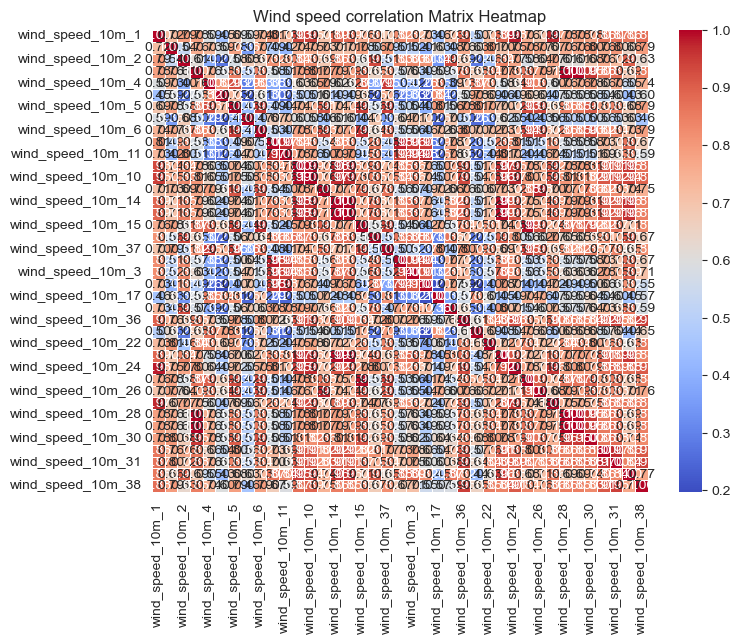

In [15]:
import seaborn as sns
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(wc, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Wind speed correlation Matrix Heatmap')
plt.show()

In [16]:
# Unstack the correlation matrix to get pairs
correlation_pairs = wc.unstack()

# Filter out self-correlations and duplicate pairs
# Use np.triu to get upper triangle and set lower triangle to NaN
# Then unstack and drop NaNs
upper_triangle = wc.where(np.triu(np.ones(wc.shape), k=1).astype(bool))
sorted_correlations = upper_triangle.unstack().dropna().sort_values(ascending=False, key=abs)

print("\nMost Correlated Column Pairs (sorted by absolute correlation):\n", sorted_correlations)


Most Correlated Column Pairs (sorted by absolute correlation):
 wind_speed_10m_13  wind_speed_10m_14    1.000000
wind_speed_10m_29  wind_speed_10m_28    1.000000
                   wind_speed_10m_8     1.000000
wind_speed_10m_28  wind_speed_10m_8     1.000000
wind_speed_10m_25  wind_speed_10m_15    0.993090
                                          ...   
wind_speed_10m_17  wind_speed_10m_11    0.246126
wind_speed_10m_39  wind_speed_10m_23    0.229114
wind_speed_10m_17  wind_speed_10m_16    0.203663
wind_speed_10m_16  wind_speed_10m_23    0.201961
wind_speed_10m_20  wind_speed_10m_16    0.197093
Length: 741, dtype: float64
